## Prudential risk prediction

KATE expects your code to define variables with specific names that correspond to certain things we are interested in.

KATE will run your notebook from top to bottom and check the latest value of those variables, so make sure you don't overwrite them.

* Remember to uncomment the line assigning the variable to your answer and don't change the variable or function names.
* Use copies of the original or previous DataFrames to make sure you do not overwrite them by mistake.

You will find instructions below about how to define each variable.

Once you're happy with your code, upload your notebook to KATE to check your feedback.

We will work with a dataset published by an insurance company which contains anonymised information about their clients.

The aim is to predict people's risk profile based on their properties.

You will be given a description of the data set and the goal is to develop a prediction model.

##  Dataset

The data provided consists of three csv files in the `data/` folder:
* `X_train.csv`: the training set
* `y_train.csv`: the target for the training set, valued from 1 to 8
* `X_test.csv`: the test set that will be evaluated

Below we give the description of the data features, some categorical, others numerical. The dataset has been thoroughly anonymised, which makes it extra challenging. 

Although the risk profile is ordered, we will consider this problem as being a classification problem and the exact category accuracy will be used for evaluating your model. It has low signal, and an 8-classes classification problem, hence accuracy can be quite low.

## Get Started

Your task is to train a model to predict the target variable. You should save the predictions for the test set in the variable called `y_pred`, which will be evaluated against the ground truth. Below we give you a sample baseline implementation.

You are free to use all your modelling skills to get the best possible performance.

Good luck!

### Dataset info

**Variable descriptions:**
- Id - A unique identifier associated with an application.
- Product_Info_1-7 - A set of normalised variables relating to the product applied for
- Ins_Age - Normalised age of applicant
- Ht - Normalised height of applicant
- Wt - Normalised weight of applicant
- BMI - Normalised BMI of applicant
- Employment_Info_1-6 - A set of normalised variables relating to the employment history of the applicant.
- InsuredInfo_1-6 - A set of normalised variables providing information about the applicant.
- Insurance_History_1-9 - A set of normalised variables relating to the insurance history of the applicant.
- Family_Hist_1-5 - A set of normalised variables relating to the family history of the applicant.
- Medical_History_1-41 - A set of normalised variables relating to the medical history of the applicant.
- Medical_Keyword_1-48 - A set of dummy variables relating to the presence of/absence of a medical keyword being associated with the application.
- Response - This is the target variable, an ordinal variable relating to the final decision associated with an application

**Categorical (nominal) features:**
```
Product_Info_1, Product_Info_2, Product_Info_3, Product_Info_5, Product_Info_6, Product_Info_7, Employment_Info_2, Employment_Info_3, Employment_Info_5, InsuredInfo_1, InsuredInfo_2, InsuredInfo_3, InsuredInfo_4, InsuredInfo_5, InsuredInfo_6, InsuredInfo_7, Insurance_History_1, Insurance_History_2, Insurance_History_3, Insurance_History_4, Insurance_History_7, Insurance_History_8, Insurance_History_9, Family_Hist_1, Medical_History_2, Medical_History_3, Medical_History_4, Medical_History_5, Medical_History_6, Medical_History_7, Medical_History_8, Medical_History_9, Medical_History_11, Medical_History_12, Medical_History_13, Medical_History_14, Medical_History_16, Medical_History_17, Medical_History_18, Medical_History_19, Medical_History_20, Medical_History_21, Medical_History_22, Medical_History_23, Medical_History_25, Medical_History_26, Medical_History_27, Medical_History_28, Medical_History_29, Medical_History_30, Medical_History_31, Medical_History_33, Medical_History_34, Medical_History_35, Medical_History_36, Medical_History_37, Medical_History_38, Medical_History_39, Medical_History_40, Medical_History_41
```

**Continuous features:**
```
Product_Info_4, Ins_Age, Ht, Wt, BMI, Employment_Info_1, Employment_Info_4, Employment_Info_6, Insurance_History_5, Family_Hist_2, Family_Hist_3, Family_Hist_4, Family_Hist_5
```

**Discrete features:**
```
Medical_History_1, Medical_History_10, Medical_History_15, Medical_History_24, Medical_History_32
Medical_Keyword_1-48 are dummy variables.
```

### Baseline model

In [1]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import  make_column_transformer

X_train = pd.read_csv("data/X_train.csv")
y_train = pd.read_csv("data/y_train.csv")
X_test = pd.read_csv("data/X_test.csv")

categories = ["Product_Info_1", "Product_Info_2", "Product_Info_3",
              "Product_Info_5", "Product_Info_6", "Product_Info_7"]

preprocessor = make_column_transformer((OneHotEncoder(handle_unknown="ignore"), categories))
    
model = make_pipeline(preprocessor, DecisionTreeClassifier())

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

#### Load data

In [3]:
X_train = pd.read_csv("data/X_train.csv")
y_train = pd.read_csv("data/y_train.csv").values.ravel()
X_test = pd.read_csv("data/X_test.csv")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (44535, 126)
X_test: (14846, 126)


#### Inspect data

In [4]:
X_train.head()

,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,...,Medical_Keyword_39,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48
0,1,D3,26,0.487179,2,3,1,0.208955,0.745455,0.257322,...,0,0,0,0,0,0,0,0,0,0
1,1,A2,15,0.076923,2,3,1,0.089552,0.654545,0.246862,...,0,0,0,0,0,0,0,0,0,0
2,1,D4,26,0.230769,2,3,1,0.447761,0.781818,0.320084,...,0,0,0,0,0,0,0,0,0,0
3,1,D3,26,1.000000,2,1,1,0.373134,0.709091,0.269874,...,0,0,0,0,0,0,0,0,0,0
4,1,D2,29,0.076923,2,1,1,0.328358,0.672727,0.430962,...,0,1,0,0,0,0,0,0,0,0


Check missing values and class distribution:

In [5]:
print("Total missing values:", X_train.isnull().sum().sum())
print("\nClass distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Total missing values: 294735

Class distribution:
1     4683
2     4942
3      770
4     1108
5     4018
6     8436
7     6006
8    14572
Name: count, dtype: int64


#### Define categorical columns

In [6]:
categories = [
      "Product_Info_1", "Product_Info_2", "Product_Info_3", "Product_Info_5",
      "Product_Info_6", "Product_Info_7", "Employment_Info_2", "Employment_Info_3",
      "Employment_Info_5", "InsuredInfo_1", "InsuredInfo_2", "InsuredInfo_3",
      "InsuredInfo_4", "InsuredInfo_5", "InsuredInfo_6", "InsuredInfo_7",
      "Insurance_History_1", "Insurance_History_2", "Insurance_History_3",
      "Insurance_History_4", "Insurance_History_7", "Insurance_History_8",
      "Insurance_History_9", "Family_Hist_1", "Medical_History_2", "Medical_History_3",
      "Medical_History_4", "Medical_History_5", "Medical_History_6", "Medical_History_7",
      "Medical_History_8", "Medical_History_9", "Medical_History_11", "Medical_History_12",
      "Medical_History_13", "Medical_History_14", "Medical_History_16", "Medical_History_17",
      "Medical_History_18", "Medical_History_19", "Medical_History_20", "Medical_History_21",
      "Medical_History_22", "Medical_History_23", "Medical_History_25", "Medical_History_26",
      "Medical_History_27", "Medical_History_28", "Medical_History_29", "Medical_History_30",
      "Medical_History_31", "Medical_History_33", "Medical_History_34", "Medical_History_35",
      "Medical_History_36", "Medical_History_37", "Medical_History_38", "Medical_History_39",
      "Medical_History_40", "Medical_History_41"
  ]
categories = [c for c in categories if c in X_train.columns]
print(f"{len(categories)} categorical columns found")

60 categorical columns found


#### Fill missing values

In [7]:
train_medians = X_train.median(numeric_only=True)
X_train_filled = X_train.fillna(train_medians)   
X_test_filled = X_test.fillna(train_medians)                                                                                       
print("Missing after fill — train:", X_train_filled.isnull().sum().sum())                                                          
print("Missing after fill — test:", X_test_filled.isnull().sum().sum())   

Missing after fill — train: 0
Missing after fill — test: 0


#### Check remaining nulls (string columns)

In [8]:
null_cols = X_train_filled.columns[X_train_filled.isnull().any()]                                                                  
print("Columns still with nulls:", list(null_cols))                                                                                
X_train_filled[null_cols] = X_train_filled[null_cols].fillna("missing")                                                            
X_test_filled[null_cols] = X_test_filled[null_cols].fillna("missing")                                                              
                                                                         

Columns still with nulls: []


#### Label encode categorical columns

In [9]:
le_dict = {}                                                                                                                       
for col in categories:                                                                                                             
    le = LabelEncoder()                                                                                                            
    X_train_filled[col] = le.fit_transform(X_train_filled[col].astype(str))                                                        
    # Handle unseen categories in test                                                                                             
    X_test_filled[col] = X_test_filled[col].astype(str).map(                                                                       
        lambda x, le=le: x if x in le.classes_ else le.classes_[0]                                                                 
    )                                                                                                                              
    X_test_filled[col] = le.transform(X_test_filled[col])                                                                          
    le_dict[col] = le                                                                                                              
print("Encoding done") 

Encoding done


#### Train model

In [10]:
model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)                                         
model.fit(X_train_filled, y_train)                                                                                                 
print("Training accuracy:", accuracy_score(y_train, model.predict(X_train_filled)))  

Training accuracy: 0.7458403502862917


#### Predict

In [11]:
y_pred = model.predict(X_test_filled)                                                                                              
print("Prediction distribution:")                                                                                                  
print(pd.Series(y_pred).value_counts().sort_index())

Prediction distribution:
1     534
2     757
3     169
4     397
5    1158
6    3477
7    1316
8    7038
Name: count, dtype: int64


#### Visualise

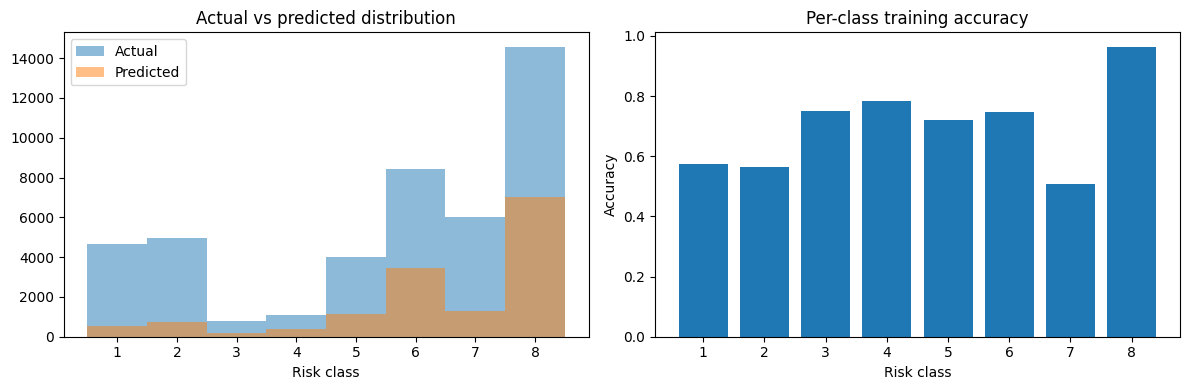

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                                                                                    
                                                                                                                                     
axes[0].hist(y_train, bins=range(1, 10), alpha=0.5, label='Actual', align='left')                                                  
axes[0].hist(y_pred, bins=range(1, 10), alpha=0.5, label='Predicted', align='left')                                                
axes[0].set_xlabel('Risk class')                                                                                                   
axes[0].set_title('Actual vs predicted distribution')                                                                              
axes[0].legend()                                                                                                                   
                                                                                                                                     
cm = confusion_matrix(y_train, model.predict(X_train_filled), labels=range(1, 9))                                                  
per_class = cm.diagonal() / cm.sum(axis=1)                                                                                         
axes[1].bar(range(1, 9), per_class)                                                                                                
axes[1].set_xlabel('Risk class')                                                                                                   
axes[1].set_ylabel('Accuracy')                                                                                                     
axes[1].set_title('Per-class training accuracy')                                                                                   
                                                                                                                                     
plt.tight_layout()                                                                                                                 
plt.show() 